In [1]:
%pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 12.5 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [prophet]m5/6 [prophet]y]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# Example time series data
data = {
    'Date': pd.date_range(start='1/1/2020', periods=24, freq='M'),
    'Value': [112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118, 132, 150, 158, 160, 172, 181, 195, 201, 210, 222, 230, 240]
}
df = pd.DataFrame(data)

# Renaming columns to fit Prophet's requirements
prophet_df = df.rename(columns={'Date': 'ds', 'Value': 'y'})

/var/folders/f3/3kqpjfqj03s00nxsf6rppv280000gn/T/ipykernel_31884/2023662490.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Date': pd.date_range(start='1/1/2020', periods=24, freq='M'),


In [3]:
prophet_df.head()

,ds,y
0,2020-01-31,112
1,2020-02-29,118
2,2020-03-31,132
3,2020-04-30,129
4,2020-05-31,121


In [4]:
from prophet import Prophet

# Initializing the model
model = Prophet()

# Fitting the model
model.fit(prophet_df)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
14:25:56 - cmdstanpy - INFO - Chain [1] start processing
14:25:56 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
# Initializing the model with yearly seasonality
model = Prophet(yearly_seasonality=True)
model.fit(prophet_df)

14:26:23 - cmdstanpy - INFO - Chain [1] start processing
14:26:24 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
# Creating a dataframe for future dates
future = model.make_future_dataframe(periods=12, freq='M')

# Making predictions
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

           ds        yhat  yhat_lower  yhat_upper
31 2022-08-31  246.163683  226.252171  265.095342
32 2022-09-30  247.021393  227.136262  266.300893
33 2022-10-31  265.950852  246.546953  283.887724
34 2022-11-30  289.365272  270.597151  307.459493
35 2022-12-31  305.070633  284.676998  324.291106


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


/var/folders/f3/3kqpjfqj03s00nxsf6rppv280000gn/T/ipykernel_31884/1015050287.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


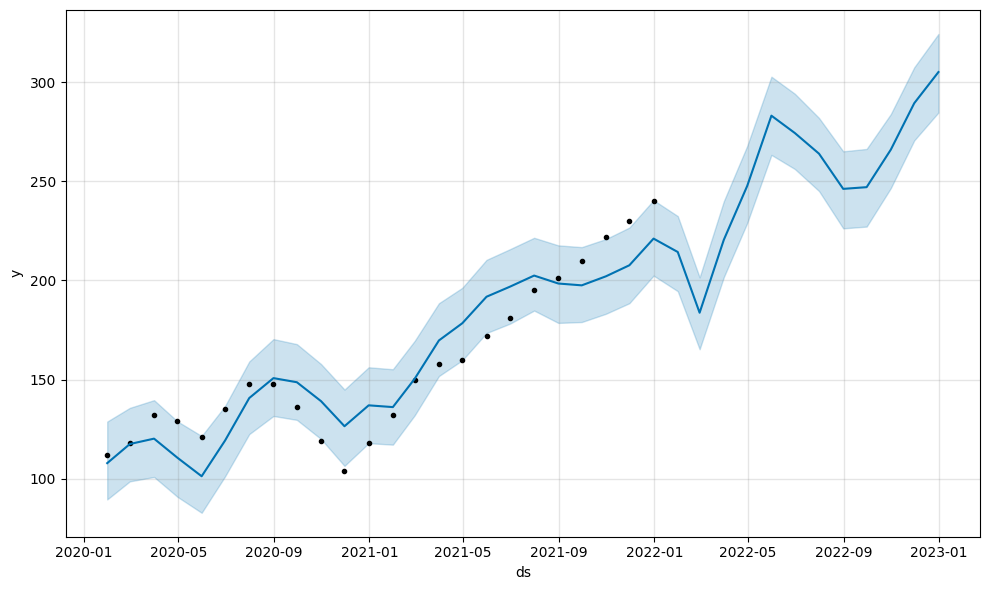

In [14]:
# Plotting the forecast
fig = model.plot(forecast)
fig.show()